# Tratamento de dados de tempo

In [ ]:
import pandas as pd
import seaborn as sns
import statistics as sts

In [ ]:
dataset = pd.read_csv('tempo.csv', sep=';')

In [ ]:
dataset.head()

,Aparencia,Temperatura,Umidade,Vento,Jogar
0,sol,85,85.0,FALSO,nao
1,sol,80,90.0,VERDADEIRO,nao
2,nublado,83,86.0,FALSO,sim
3,chuva,70,NaN,FALSO,sim
4,chuva,68,80.0,FALSO,sim


In [ ]:
dataset.shape

(14, 5)

# Análise de dados - dados textuais

### Aparência

In [ ]:
agrupado = dataset.groupby(['Aparencia']).size()
agrupado

,0
Aparencia,
chuva,5
menos,1
nublado,3
sol,5


<Axes: xlabel='Aparencia'>

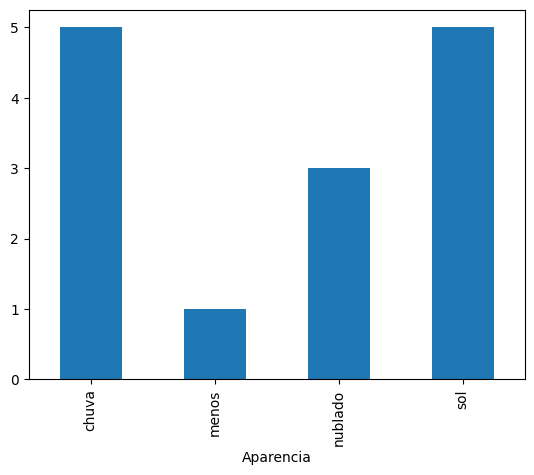

In [ ]:
agrupado.plot.bar()

### Jogar

In [ ]:
agrupado = dataset.groupby(['Jogar']).size()
agrupado

,0
Jogar,
nao,5
sim,9


<Axes: xlabel='Jogar'>

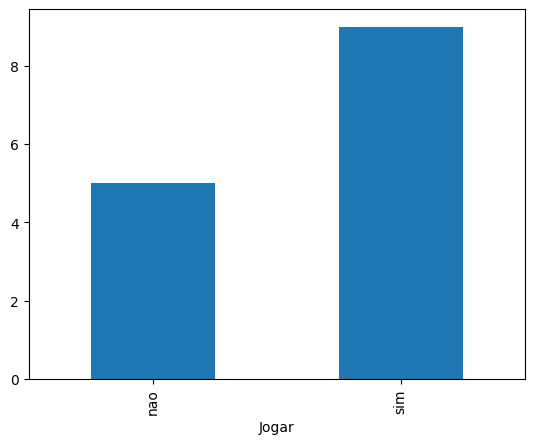

In [ ]:
agrupado.plot.bar()

### Vento

In [ ]:
agrupado = dataset.groupby(['Vento']).size()
agrupado

,0
Vento,
FALSO,7
VERDADEIRO,6


<Axes: xlabel='Vento'>

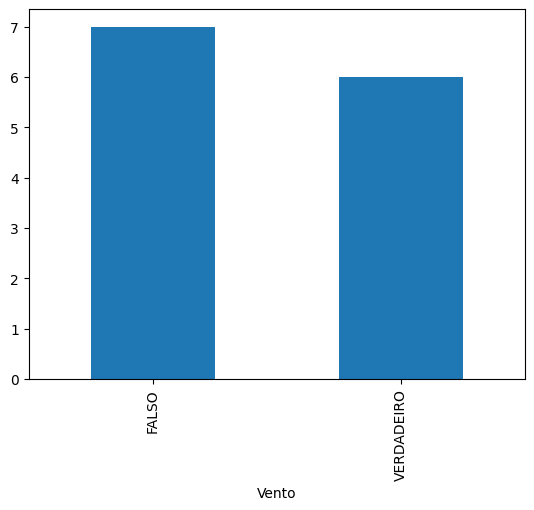

In [ ]:
agrupado.plot.bar()

# Análise de dados - dados numéricos

### Temperatura

In [ ]:
dataset['Temperatura'].describe()

,Temperatura
count,14.000000
mean,155.571429
std,306.433759
min,64.000000
25%,69.250000
50%,73.500000
75%,80.750000
max,1220.000000


<Axes: ylabel='Temperatura'>

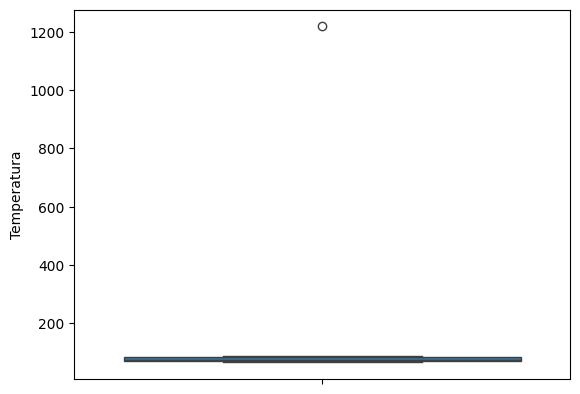

In [ ]:
sns.boxplot(dataset['Temperatura'])

/tmp/ipykernel_1389/820062868.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Temperatura'])


<Axes: xlabel='Temperatura', ylabel='Density'>

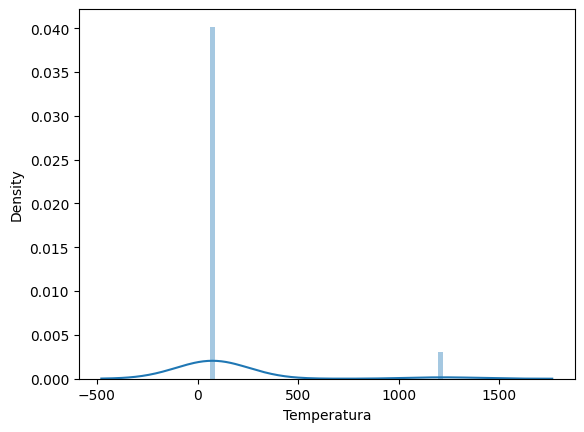

In [ ]:
sns.distplot(dataset['Temperatura'])

### Umidade

In [ ]:
dataset['Umidade'].describe()

,Umidade
count,13.000000
mean,89.769231
std,34.540203
min,65.000000
25%,70.000000
50%,85.000000
75%,90.000000
max,200.000000


<Axes: ylabel='Umidade'>

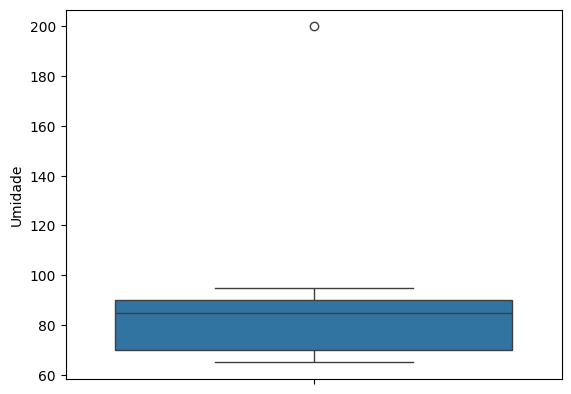

In [ ]:
sns.boxplot(dataset['Umidade'])

/tmp/ipykernel_1389/2487411159.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Umidade'])


<Axes: xlabel='Umidade', ylabel='Density'>

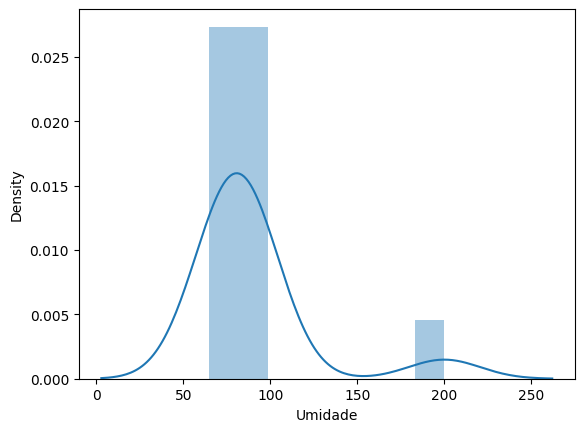

In [ ]:
sns.distplot(dataset['Umidade'])

# Tratamento de dados

## Tratamento de dados ausentes/nulos

In [ ]:
dataset.isnull().sum()

,0
Aparencia,0
Temperatura,0
Umidade,1
Vento,1
Jogar,0


### Vento

In [ ]:
dataset['Vento'].fillna('FALSO', inplace=True)

/tmp/ipykernel_1389/3401709182.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Vento'].fillna('FALSO', inplace=True)


In [ ]:
dataset['Vento'].isnull().sum()

np.int64(0)

### Umidade

In [ ]:
mediana = sts.median(dataset['Umidade'])
mediana

85.5

In [ ]:
dataset['Umidade'].fillna(mediana, inplace=True)

/tmp/ipykernel_1389/3731535888.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Umidade'].fillna(mediana, inplace=True)


In [ ]:
dataset['Umidade'].isnull().sum()

np.int64(0)

In [ ]:
dataset.isnull().sum()

,0
Aparencia,0
Temperatura,0
Umidade,0
Vento,0
Jogar,0


## Tratamento de dados errados

### Aparência

In [ ]:
dataset.loc[dataset['Aparencia'] == 'menos', 'Aparencia'] = 'sol'

In [ ]:
agrupado = dataset.groupby(['Aparencia']).size()
agrupado

,0
Aparencia,
chuva,5
nublado,3
sol,6


### Temperatura

In [ ]:
mediana = sts.median(dataset['Temperatura'])
mediana

73.5

In [ ]:
dataset.loc[dataset['Temperatura'] > 130, 'Temperatura'] = mediana

/tmp/ipykernel_1389/1632236948.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '73.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset.loc[dataset['Temperatura'] > 130, 'Temperatura'] = mediana


In [ ]:
dataset.loc[dataset['Temperatura'] > 130, 'Temperatura']

,Temperatura


### Umidade

In [ ]:
mediana = sts.median(dataset['Umidade'])
mediana

85.25

In [ ]:
dataset.loc[dataset['Umidade'] > 100, 'Umidade'] = mediana

In [ ]:
dataset.loc[dataset['Umidade'] > 100, 'Umidade']

,Umidade


# Validacao dos dados

In [ ]:
agrupado = dataset.groupby(['Aparencia']).size()
agrupado

,0
Aparencia,
chuva,5
nublado,3
sol,6


<Axes: xlabel='Aparencia'>

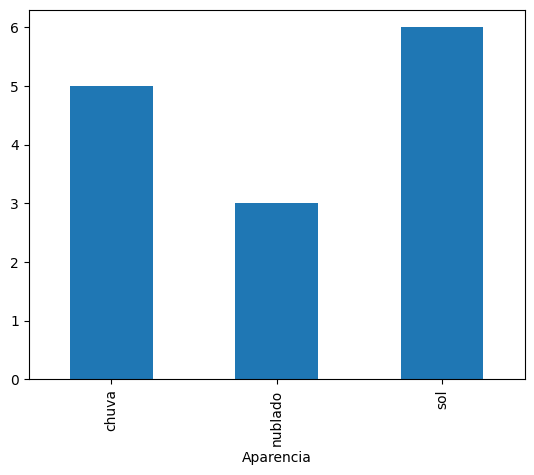

In [ ]:
agrupado.plot.bar()

In [ ]:
agrupado = dataset.groupby(['Jogar']).size()
agrupado

,0
Jogar,
nao,5
sim,9


<Axes: xlabel='Jogar'>

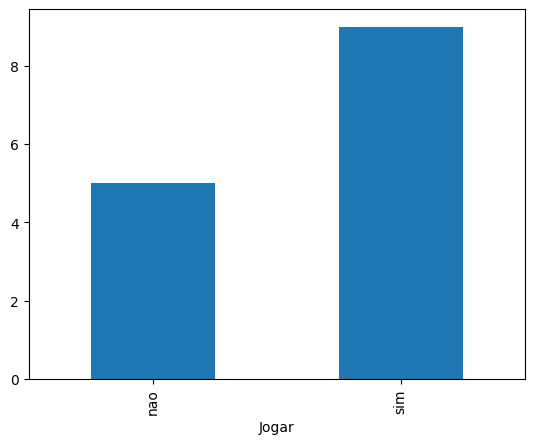

In [ ]:
agrupado.plot.bar()

In [ ]:
agrupado = dataset.groupby(['Vento']).size()
agrupado

,0
Vento,
FALSO,8
VERDADEIRO,6


<Axes: xlabel='Vento'>

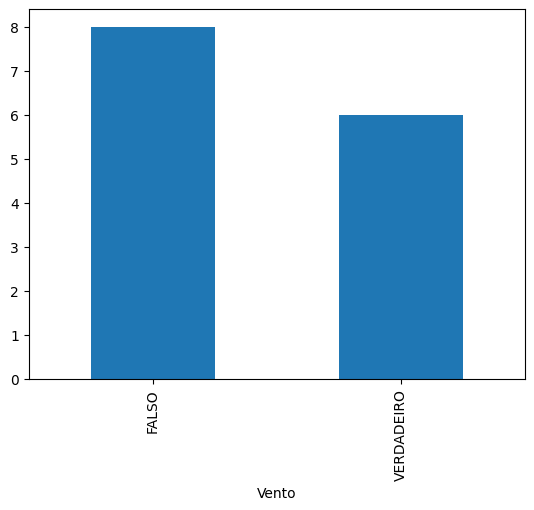

In [ ]:
agrupado.plot.bar()

In [ ]:
dataset['Temperatura'].describe()

,Temperatura
count,14.000000
mean,73.678571
std,6.556286
min,64.000000
25%,69.250000
50%,72.750000
75%,78.750000
max,85.000000


<Axes: ylabel='Temperatura'>

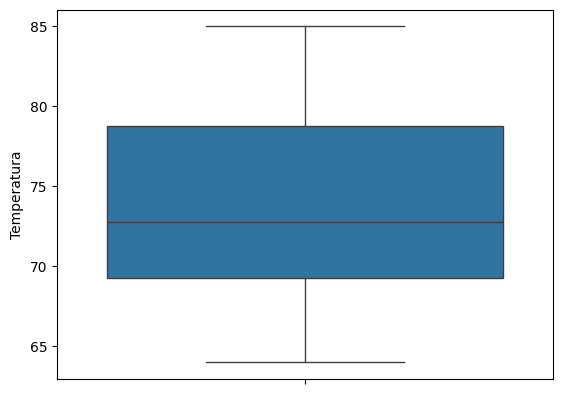

In [ ]:
sns.boxplot(dataset['Temperatura'])

/tmp/ipykernel_1389/820062868.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Temperatura'])


<Axes: xlabel='Temperatura', ylabel='Density'>

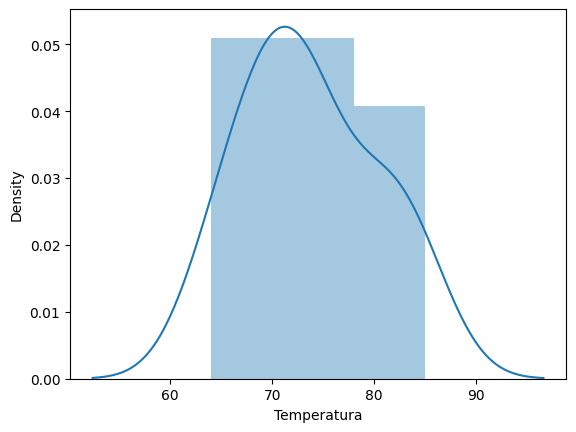

In [ ]:
sns.distplot(dataset['Temperatura'])

In [ ]:
dataset['Umidade'].describe()

,Umidade
count,14.000000
mean,81.267857
std,9.576847
min,65.000000
25%,71.250000
50%,85.125000
75%,89.000000
max,95.000000


<Axes: ylabel='Umidade'>

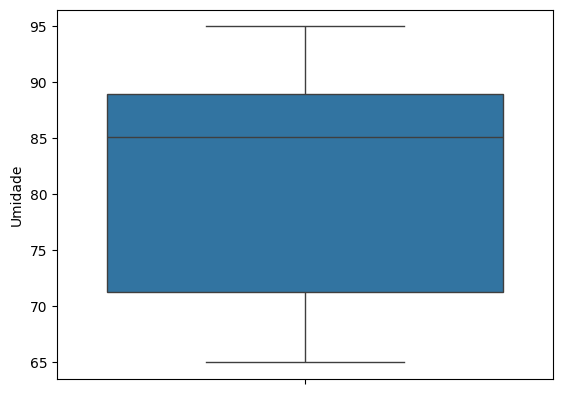

In [ ]:
sns.boxplot(dataset['Umidade'])

/tmp/ipykernel_1389/2487411159.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Umidade'])


<Axes: xlabel='Umidade', ylabel='Density'>

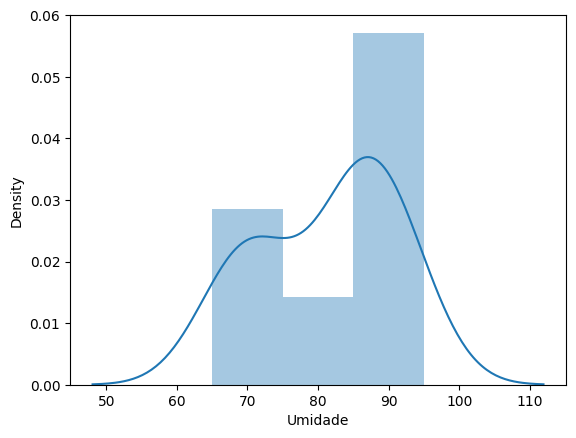

In [ ]:
sns.distplot(dataset['Umidade'])